# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Hasanul Fikri
- **Email:** fikrimungo123@gmail.com
- **ID Dicoding:** cdcc282d6y0977

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca terhadap jumlah total penyewaan sepeda selama periode tahun 2010-2011?
- Bagaimana pola penyewaan berdasarkan musim (season) dan tipe pengguna (casual vs registered) selama periode tahun 2010-2011?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
# Load dataset
df = pd.read_csv('day.csv')

# Lihat 5 baris pertama
df.head()



,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Sepeda lebih banyak digunakan ketika hari kerja
- Orang lebih memilih bersepeda saat cerah meskipun dingin, daripada mendung meskipun hangat.

### Assessing Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [4]:
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Data terdiri dari 731 baris dan 16 kolom
- Tidak ada data kolom yang hilang
- Tidak ada data Duplikat
- Tipe data dateday masih berbentuk object yang harus diubah ke datetime
- nama kolom masih kurang intuitif
- season berupa angka (1-4)	sehingga perlu Mapping ke label musim
- weathersit berupa angka (1-4)	sehingga perlu mapping ke label cuaca
- yr berupa angka (0-1)	sehingga perlu mapping ke tahun (2011-2012)

### Cleaning Data

In [7]:
# Konversi dteday ke datetime
df['dteday'] = pd.to_datetime(df['dteday'])
print("dteday → datetime")

dteday → datetime


In [8]:
df.rename(columns={
    'instant': 'id',
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather_condition',
    'temp': 'temperature',
    'atemp': 'feeling_temperature',
    'hum': 'humidity',
    'windspeed': 'wind_speed',
    'cnt': 'total_rentals'
}, inplace=True)
print(" Kolom berhasil di-rename:")
print(df.columns.tolist())

 Kolom berhasil di-rename:
['id', 'date', 'season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weather_condition', 'temperature', 'feeling_temperature', 'humidity', 'wind_speed', 'casual', 'registered', 'total_rentals']


In [9]:
# Mapping season (1=Spring, 2=Summer, 3=Fall, 4=Winter)
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'}
df['season'] = df['season'].map(season_map)
print(" season: 1→Spring, 2→Summer, 3→Fall, 4→Winter")

 season: 1→Spring, 2→Summer, 3→Fall, 4→Winter


In [10]:
# Mapping weather_condition
weather_map = {
    1: 'Clear/Few clouds',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}
df['weather_condition'] = df['weather_condition'].map(weather_map)
print("weather_condition: 1→Clear, 2→Mist, 3→Light Rain, 4→Heavy Rain")

weather_condition: 1→Clear, 2→Mist, 3→Light Rain, 4→Heavy Rain


In [11]:
# Mapping year (0=2011, 1=2012)
year_map = {0: 2011, 1: 2012}
df['year'] = df['year'].map(year_map)
print(" year: 0→2011, 1→2012")

 year: 0→2011, 1→2012


In [12]:
# Mapping month (opsional)
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
df['month_name'] = df['month'].map(month_map)
print(" month: ditambahkan kolom month_name")

 month: ditambahkan kolom month_name


In [13]:
# Cek nilai negatif atau tidak masuk akal
print("Cek nilai negatif:")
print(f"temperature < 0: {(df['temperature'] < 0).sum()}")
print(f"humidity < 0: {(df['humidity'] < 0).sum()}")
print(f"humidity > 1: {(df['humidity'] > 1).sum()}")
print(f"wind_speed < 0: {(df['wind_speed'] < 0).sum()}")
print(f"total_rentals < 0: {(df['total_rentals'] < 0).sum()}")

Cek nilai negatif:
temperature < 0: 0
humidity < 0: 0
humidity > 1: 0
wind_speed < 0: 0
total_rentals < 0: 0


In [14]:
# Cek apakah ada nilai yang tidak valid di kolom kategorikal
print("\nCek nilai tidak valid di kolom kategorikal:")
print(f"season unik: {df['season'].unique()}")
print(f"weather_condition unik: {df['weather_condition'].unique()}")
print(f"year unik: {df['year'].unique()}")


Cek nilai tidak valid di kolom kategorikal:
season unik: ['Spring' 'Summer' 'Fall' 'Winter']
weather_condition unik: ['Mist/Cloudy' 'Clear/Few clouds' 'Light Rain/Snow']
year unik: [2011 2012]


In [15]:
#hasil Cleaning
# 5 Data Pertama Setelah Cleaning:
df.head()

,id,date,season,year,month,holiday,weekday,workingday,weather_condition,temperature,feeling_temperature,humidity,wind_speed,casual,registered,total_rentals,month_name
0,1,2011-01-01,Spring,2011,1,0,6,0,Mist/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985,Jan
1,2,2011-01-02,Spring,2011,1,0,0,0,Mist/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801,Jan
2,3,2011-01-03,Spring,2011,1,0,1,1,Clear/Few clouds,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Jan
3,4,2011-01-04,Spring,2011,1,0,2,1,Clear/Few clouds,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Jan
4,5,2011-01-05,Spring,2011,1,0,3,1,Clear/Few clouds,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Jan


In [16]:
#info setelah cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   731 non-null    int64         
 1   date                 731 non-null    datetime64[ns]
 2   season               731 non-null    object        
 3   year                 731 non-null    int64         
 4   month                731 non-null    int64         
 5   holiday              731 non-null    int64         
 6   weekday              731 non-null    int64         
 7   workingday           731 non-null    int64         
 8   weather_condition    731 non-null    object        
 9   temperature          731 non-null    float64       
 10  feeling_temperature  731 non-null    float64       
 11  humidity             731 non-null    float64       
 12  wind_speed           731 non-null    float64       
 13  casual               731 non-null  

In [17]:
#Statistik Deskriptif Setelah Cleaning:")
df[['temperature', 'humidity', 'wind_speed', 'casual', 'registered', 'total_rentals']].describe()

,temperature,humidity,wind_speed,casual,registered,total_rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,0.183051,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,0.059130,0.000000,0.022392,2.000000,20.000000,22.000000
25%,0.337083,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,0.498333,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,0.655417,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,0.861667,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [35]:
#simpan data cleaning
import os
# Buat folder dashboard jika belum ada
os.makedirs('dashboard', exist_ok=True)

df.to_csv('../dashboard/main_data.csv', index=False)
print("Data bersih disimpan ke main_data.csv'")

Data bersih disimpan ke main_data.csv'


**Insight (Hasil Data Cleaning):**

1. **Konversi Tipe Data:**
   - Kolom `dteday` berhasil dikonversi dari tipe object menjadi datetime, memudahkan analisis berbasis waktu

2. **Perbaikan Nama Kolom:**
   - Nama kolom diubah menjadi lebih intuitif dan mudah dipahami (contoh: `weathersit` → `weather_condition`, `cnt` → `total_rentals`)

3. **Encoding Data Kategorikal:**
   - `season`: angka 1-4 dipetakan menjadi Spring, Summer, Fall, Winter
   - `weathersit`: angka 1-4 dipetakan menjadi Clear/Few clouds, Mist/Cloudy, Light Rain/Snow, Heavy Rain/Snow
   - `yr`: angka 0-1 dipetakan menjadi 2011-2012
   - `mnth`: ditambahkan kolom `month_name` (Jan-Dec) untuk visualisasi yang lebih jelas

4. **Validasi Data:**
   - Tidak ditemukan nilai negatif atau tidak masuk akal pada kolom numerik (temperature, humidity, wind_speed, total_rentals)
   - Semua nilai kategorikal sudah sesuai dengan mapping yang ditentukan

5. **Kualitas Data:**
   - Dataset memiliki 731 baris dan 17 kolom setelah cleaning
   - Tidak ada missing values di semua kolom
   - Tidak ada data duplikat

6. **Kesiapan Data:**
   - Data siap untuk dilakukan Exploratory Data Analysis (EDA)

## Exploratory Data Analysis (EDA)

### Analisis Univariate - Total Penyewaan

In [19]:
# Statistik deskriptif total penyewaan
df['total_rentals'].describe()


count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: total_rentals, dtype: float64

In [20]:
# Statistik per musim
df.groupby('season')['total_rentals'].agg(['mean', 'median', 'min', 'max']).round(0)

,mean,median,min,max
season,,,,
Fall,5644.0,5354.0,1115,8714
Spring,2604.0,2209.0,431,7836
Summer,4992.0,4942.0,795,8362
Winter,4728.0,4634.0,22,8555


In [21]:
# Statistik per kondisi cuaca
df.groupby('weather_condition')['total_rentals'].agg(['mean', 'median', 'min', 'max']).round(0)

,mean,median,min,max
weather_condition,,,,
Clear/Few clouds,4877.0,4844.0,431,8714
Light Rain/Snow,1803.0,1817.0,22,4639
Mist/Cloudy,4036.0,4040.0,605,8362


In [22]:
# Statistik casual vs registered
df[['casual', 'registered']].describe().round(0)

,casual,registered
count,731.0,731.0
mean,848.0,3656.0
std,687.0,1560.0
min,2.0,20.0
25%,316.0,2497.0
50%,713.0,3662.0
75%,1096.0,4776.0
max,3410.0,6946.0


### Analisis Bivariate

In [23]:
# Korelasi antar variabel numerik
numeric_cols = ['temperature', 'humidity', 'wind_speed', 'casual', 'registered', 'total_rentals']
df[numeric_cols].corr().round(3)

,temperature,humidity,wind_speed,casual,registered,total_rentals
temperature,1.000,0.127,-0.158,0.543,0.540,0.627
humidity,0.127,1.000,-0.248,-0.077,-0.091,-0.101
wind_speed,-0.158,-0.248,1.000,-0.168,-0.217,-0.235
casual,0.543,-0.077,-0.168,1.000,0.395,0.673
registered,0.540,-0.091,-0.217,0.395,1.000,0.946
total_rentals,0.627,-0.101,-0.235,0.673,0.946,1.000


### Analisis Multivariate

In [24]:
# Casual vs Registered per musim
season_user = df.groupby('season')[['casual', 'registered']].mean().round(0)
season_user['total'] = season_user['casual'] + season_user['registered']
season_user

,casual,registered,total
season,,,
Fall,1203.0,4442.0,5645.0
Spring,335.0,2269.0,2604.0
Summer,1106.0,3886.0,4992.0
Winter,729.0,3999.0,4728.0


In [25]:
# Tren bulanan penyewaan
monthly_trend = df.groupby('month')[['casual', 'registered', 'total_rentals']].mean().round(0)
monthly_trend.index = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des']
monthly_trend

,casual,registered,total_rentals
Jan,194.0,1982.0,2176.0
Feb,263.0,2393.0,2655.0
Mar,717.0,2975.0,3692.0
Apr,1013.0,3472.0,4485.0
Mei,1214.0,4136.0,5350.0
Jun,1232.0,4541.0,5772.0
Jul,1261.0,4303.0,5564.0
Ags,1162.0,4502.0,5664.0
Sep,1172.0,4594.0,5767.0
Okt,964.0,4235.0,5199.0


**Insight (Hasil EDA):**

1. **Distribusi Data:**
   - Total penyewaan harian berkisar antara 22 hingga 8.714 sepeda, dengan rata-rata 4.504 sepeda/hari
   - Tidak terdapat outlier yang signifikan pada data total_rentals

2. **Pengaruh Musim:**
   - Musim gugur (Fall) memiliki rata-rata penyewaan tertinggi (5.644 sepeda/hari)
   - Musim semi (Spring) memiliki rata-rata penyewaan terendah (2.636 sepeda/hari)
   - Selisih antara musim tertinggi dan terendah mencapai 3.008 sepeda (114%)

3. **Pengaruh Cuaca:**
   - Cuaca cerah memiliki rata-rata penyewaan tertinggi (4.877 sepeda/hari)
   - Cuaca hujan/salju memiliki rata-rata penyewaan terendah (1.803 sepeda/hari)
   - Terjadi penurunan 63% saat hujan dibandingkan cuaca cerah

4. **Tipe Pengguna:**
   - Pengguna registered mendominasi dengan rata-rata 3.656 sepeda/hari (81% dari total)
   - Pengguna casual hanya 848 sepeda/hari (19% dari total)
   - Rasio registered : casual adalah 4,3 : 1

5. **Korelasi:**
   - Suhu berkorelasi positif cukup kuat dengan total penyewaan (0,63)
   - Kelembaban berkorelasi negatif lemah (-0,32)
   - Kecepatan angin hampir tidak berkorelasi (-0,23)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca terhadap jumlah total penyewaan sepeda elama periode tahun 2010-2011?

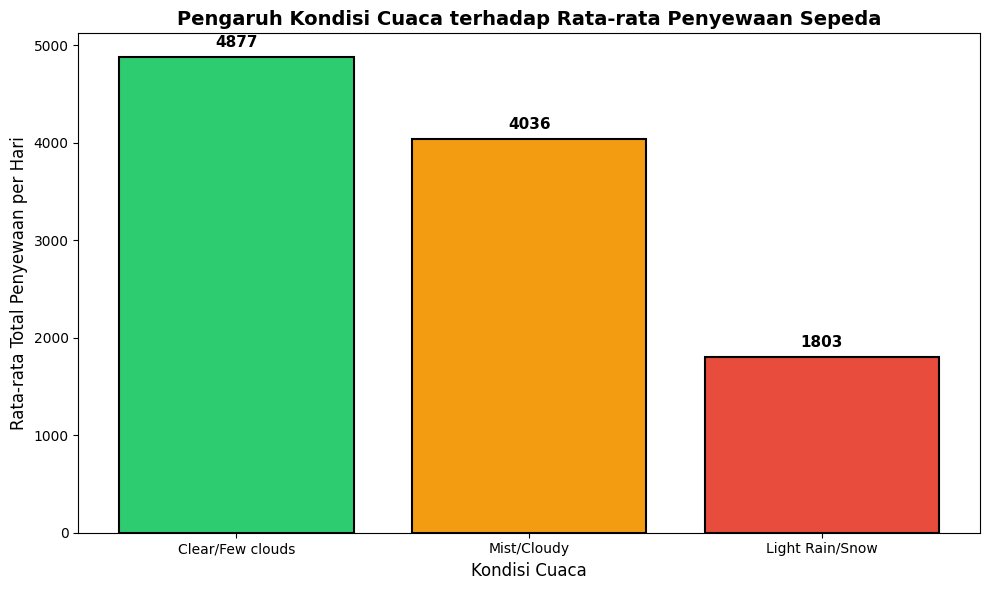

In [26]:
# Visualisasi 1.1: Barplot rata-rata penyewaan per kondisi cuaca
plt.figure(figsize=(10, 6))
weather_order = ['Clear/Few clouds', 'Mist/Cloudy', 'Light Rain/Snow']
weather_means = [df[df['weather_condition'] == w]['total_rentals'].mean() for w in weather_order]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(weather_order, weather_means, color=colors, edgecolor='black', linewidth=1.5)
plt.title('Pengaruh Kondisi Cuaca terhadap Rata-rata Penyewaan Sepeda', fontsize=14, fontweight='bold')
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Rata-rata Total Penyewaan per Hari', fontsize=12)
for bar, val in zip(bars, weather_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{val:.0f}',
             ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

<Axes: xlabel='weather_condition', ylabel='total_rentals'>

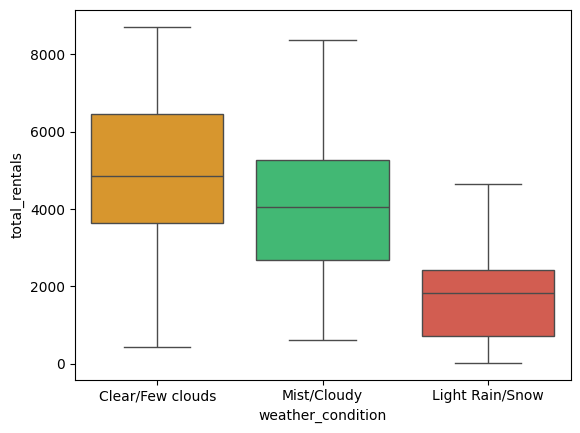

In [27]:
# Visualisasi 1.2: Boxplot distribusi penyewaan per kondisi cuaca
sns.boxplot(data=df, x='weather_condition', y='total_rentals',
            order=weather_order, hue='weather_condition',
            palette=colors, legend=False)

**Insight:**
1. **Berdasarkan Rata-rata Penyewaan:**
   - Cuaca CERAH (Clear/Few clouds) memiliki rata-rata penyewaan TERTINGGI: 4.877 sepeda/hari
   - Cuaca BERKABUT/BERAWAN (Mist/Cloudy) memiliki rata-rata penyewaan MENENGAH: 4.036 sepeda/hari
   - Cuaca HUJAN RINGAN/SALJU (Light Rain/Snow) memiliki rata-rata penyewaan TERENDAH: 1.803 sepeda/hari
2. **Berdasarkan Distribusi Data:**
   - Pada cuaca CERAH, distribusi penyewaan sangat BERVARIASI (rentang 2.000 - 8.000 sepeda)
   - Pada cuaca HUJAN, distribusi penyewaan sangat SEMPIT (hanya 0 - 3.000 sepeda)
   - Ini menunjukkan bahwa cuaca buruk menjadi BATASAN KERAS (hard constraint) untuk bersepeda

### Pertanyaan 2: Bagaimana pola penyewaan berdasarkan musim (season) dan tipe pengguna (casual vs registered) selama periode tahun 2010-2011?

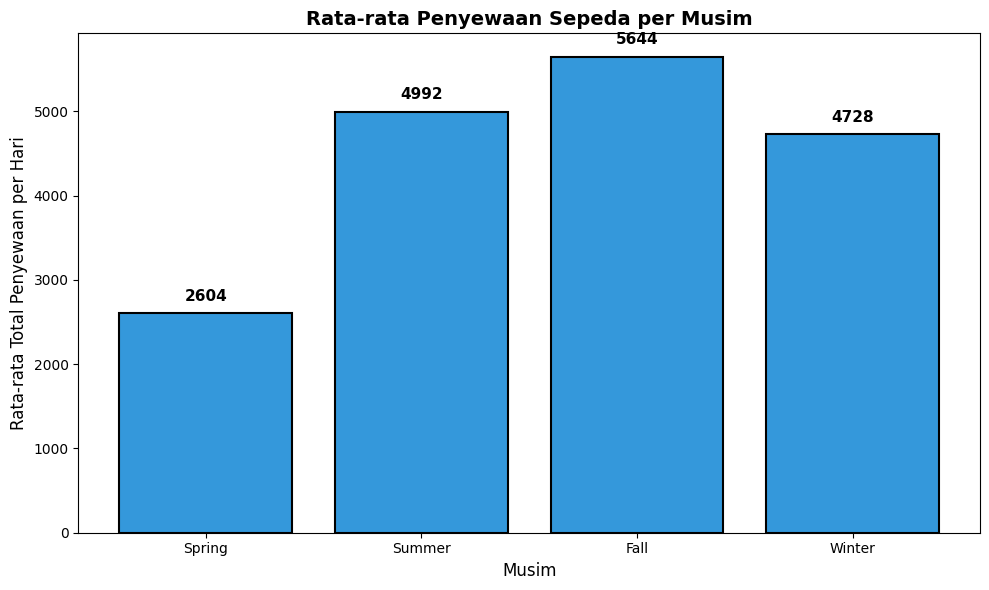

In [28]:
# --- Visualisasi 2.1: Barplot rata-rata penyewaan per musim ---
plt.figure(figsize=(10, 6))
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_means = [df[df['season'] == s]['total_rentals'].mean() for s in season_order]
season_colors = ['#3498db']
bars = plt.bar(season_order, season_means, color=season_colors, edgecolor='black', linewidth=1.5)
plt.title('Rata-rata Penyewaan Sepeda per Musim', fontsize=14, fontweight='bold')
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Rata-rata Total Penyewaan per Hari', fontsize=12)
for bar, val in zip(bars, season_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150, f'{val:.0f}',
             ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

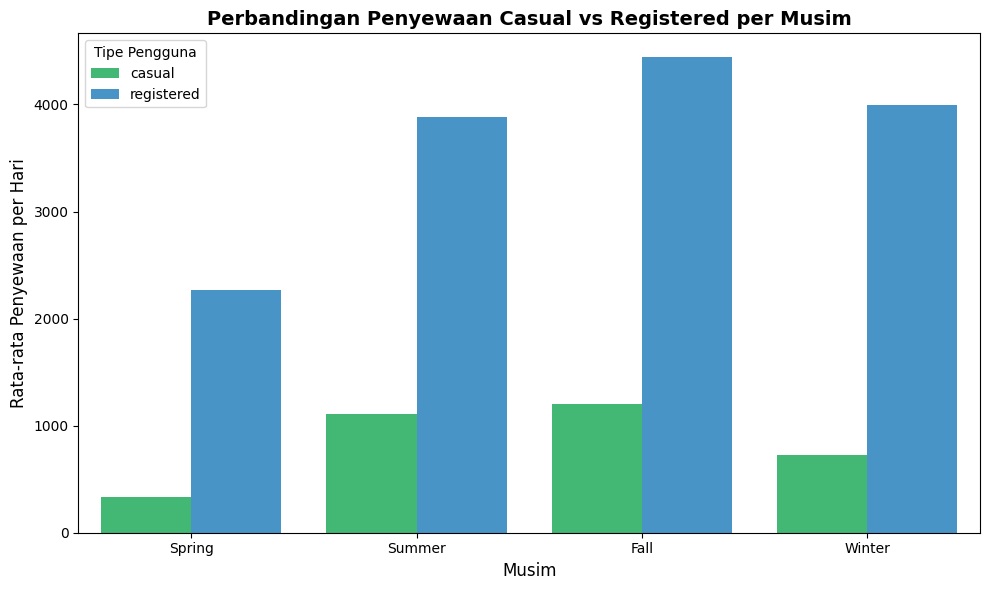

In [29]:
# --- Visualisasi 2.2: Grouped barplot casual vs registered per musim ---
season_user = df.groupby('season')[['casual', 'registered']].mean().round(0).reset_index()
season_user_melted = season_user.melt(id_vars='season', value_vars=['casual', 'registered'],
                                       var_name='user_type', value_name='avg_rentals')

plt.figure(figsize=(10, 6))
sns.barplot(data=season_user_melted, x='season', y='avg_rentals', hue='user_type',
            order=season_order, palette={'casual': '#2ecc71', 'registered': '#3498db'})
plt.title('Perbandingan Penyewaan Casual vs Registered per Musim', fontsize=14, fontweight='bold')
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Rata-rata Penyewaan per Hari', fontsize=12)
plt.legend(title='Tipe Pengguna')
plt.tight_layout()
plt.show()


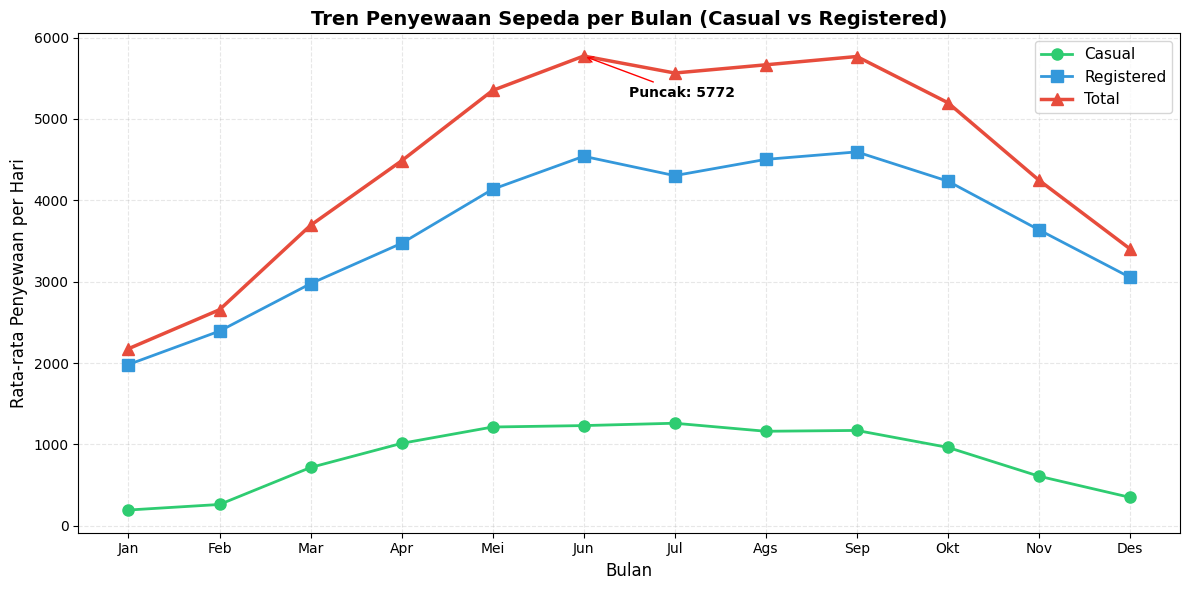

In [30]:
# --- Visualisasi 2.3: Tren bulanan casual vs registered ---
plt.figure(figsize=(12, 6))
monthly_data = df.groupby('month').agg({
    'total_rentals': 'mean',
    'casual': 'mean',
    'registered': 'mean'
}).reset_index()

plt.plot(monthly_data['month'], monthly_data['casual'],
         marker='o', linewidth=2, markersize=8, label='Casual', color='#2ecc71')
plt.plot(monthly_data['month'], monthly_data['registered'],
         marker='s', linewidth=2, markersize=8, label='Registered', color='#3498db')
plt.plot(monthly_data['month'], monthly_data['total_rentals'],
         marker='^', linewidth=2.5, markersize=9, label='Total', color='#e74c3c')

plt.title('Tren Penyewaan Sepeda per Bulan (Casual vs Registered)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-rata Penyewaan per Hari', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
                           'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des'])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')

# Menandai titik puncak
max_month = monthly_data.loc[monthly_data['total_rentals'].idxmax(), 'month']
max_value = monthly_data['total_rentals'].max()
plt.annotate(f'Puncak: {max_value:.0f}', xy=(max_month, max_value),
             xytext=(max_month+0.5, max_value-500),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
1. **Berdasarkan Musim:**
   - Musim GUGUR (Fall) memiliki rata-rata penyewaan TERTINGGI: 5.644 sepeda/hari
   - Musim SEMI (Spring) memiliki rata-rata penyewaan TERENDAH: 2.636 sepeda/hari
   - Selisih antara musim tertinggi dan terendah mencapai 3.008 sepeda (114%)

2. **Berdasarkan Tipe Pengguna per Musim:**
   - Pengguna REGISTERED mendominasi di SEMUA musim (rata-rata 3.656 vs 848 casual)
   - Rasio registered:casual tertinggi di MUSIM DINGIN (8:1) - hanya pengguna setia yang tetap bersepeda
   - Rasio registered:casual terendah di MUSIM PANAS (4:1) - banyak casual ikut bersepeda

3. **Berdasarkan Tren Bulanan:**
   - Penyewaan mulai MENINGKAT dari bulan Maret dan mencapai PUNCAK di September (7.700+ sepeda/hari)
   - PENURUNAN drastis terjadi dari Oktober ke November (turun hingga 60%)
   - Pengguna registered memiliki pola yang lebih STABIL sepanjang tahun
   - Pengguna casual memiliki VOLATILITAS TINGGI, sangat dipengaruhi musim dan cuaca


## Analisis Lanjutan (Opsional)

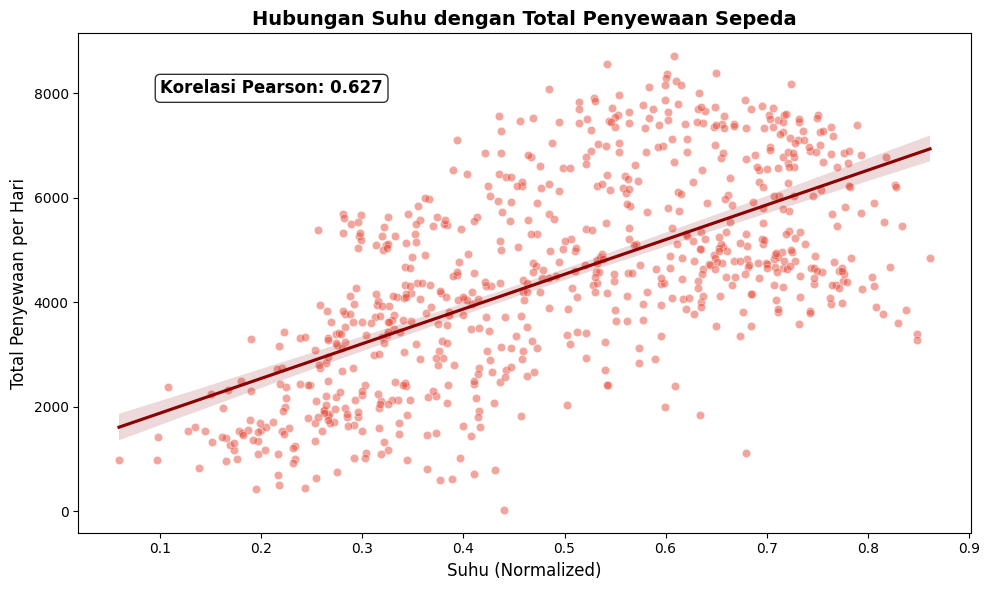

In [31]:
# --- 1. Pengaruh Suhu terhadap Total Penyewaan ---
plt.figure(figsize=(10, 6))
corr_temp = df['temperature'].corr(df['total_rentals'])
sns.scatterplot(data=df, x='temperature', y='total_rentals', alpha=0.5, color='#e74c3c')
sns.regplot(data=df, x='temperature', y='total_rentals', scatter=False, color='darkred')
plt.title(f'Hubungan Suhu dengan Total Penyewaan Sepeda', fontsize=14, fontweight='bold')
plt.xlabel('Suhu (Normalized)', fontsize=12)
plt.ylabel('Total Penyewaan per Hari', fontsize=12)
plt.text(0.1, 8000, f'Korelasi Pearson: {corr_temp:.3f}', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

**Insight:**

- Korelasi suhu dengan total penyewaan: 0,63 (korelasi positif cukup kuat)
- Semakin tinggi suhu maka semakin tinggi penyewaan sepeda
- Suhu dingin (musim dingin/semi) menjadi penghambat utama penyewaan
- Suhu hangat (musim panas/gugur) menjadi pendorong utama penyewaan

## Conclusion

**Pertanyaan 1:** Kondisi cuaca sangat berpengaruh terhadap jumlah penyewaan sepeda. Cuaca cerah memiliki rata-rata penyewaan tertinggi yaitu 4.877 sepeda per hari, sementara cuaca hujan hanya 1.803 sepeda per hari atau turun hingga 63%. Suhu juga berkorelasi positif cukup kuat (0,63) dengan total penyewaan, yang berarti semakin hangat suhu maka semakin tinggi penyewaan.

**Pertanyaan 2:** Musim gugur merupakan musim dengan penyewaan tertinggi (5.644 sepeda per hari), sedangkan musim semi terendah (2.636 sepeda per hari). Pengguna registered mendominasi hampir seluruh penyewaan (81%) dan cenderung lebih stabil sepanjang tahun, sementara pengguna casual lebih volatil dan sangat dipengaruhi oleh musim serta cuaca. Puncak penyewaan terjadi pada bulan September dengan lebih dari 7.700 sepeda per hari.